# Spotify Content Analytics

**Business problem:** Analyze genre trends, audio features, and engagement (popularity)
across a music catalog.

**Skills:** SQL + Python · Correlation & distribution analysis · Visualization · Data storytelling

---
Companion to the Netflix project — same pipeline skeleton, but the analysis leans on
**numeric audio features** and a real **engagement metric** (`popularity`, 0–100).
That `popularity` column is the key thing Netflix lacked, and it's what powers the
**Phase 7** comparison between the two platforms.

Scaffolded sections are done; **YOUR TURN** sections are where you build the analysis.


## Phase 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print("Libraries loaded.")

Libraries loaded.


## Phase 1 — Load & get your bearings

Note the path: the CSV lives in `../data/` relative to this notebook in `notebooks/`.

In [2]:
df = pd.read_csv("../data/spotify_tracks.csv")
print("Shape:", df.shape)
df.head()

Shape: (5020, 14)


,track_id,track_name,artist,genre,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,valence,tempo,duration_ms
0,t1,Track 1,Artist G5,r&b,65.0,0.639,0.595,-11.28,0.050,0.140,0.000,0.438,119.68,290412
1,t2,Track 2,Artist H4,hip-hop,52.0,0.776,0.520,-11.55,0.219,0.305,0.003,0.308,64.77,132627
2,t3,Track 3,Artist O13,pop,61.0,0.652,0.724,-7.07,0.051,0.000,0.000,0.503,121.17,118191
3,t4,Track 4,Artist C3,hip-hop,49.0,0.913,0.655,-7.99,0.335,0.075,0.322,0.530,119.79,136496
4,t5,Track 5,Artist W8,jazz,50.0,0.454,0.418,-14.88,0.069,1.000,0.187,0.637,120.09,244601


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          5020 non-null   str    
 1   track_name        5020 non-null   str    
 2   artist            5020 non-null   str    
 3   genre             4970 non-null   str    
 4   popularity        4944 non-null   float64
 5   danceability      5020 non-null   float64
 6   energy            5020 non-null   float64
 7   loudness          5020 non-null   float64
 8   speechiness       5020 non-null   float64
 9   acousticness      5020 non-null   float64
 10  instrumentalness  5020 non-null   float64
 11  valence           5020 non-null   float64
 12  tempo             4919 non-null   float64
 13  duration_ms       5020 non-null   int64  
dtypes: float64(9), int64(1), str(4)
memory usage: 549.2 KB


In [4]:
df.isnull().sum()

track_id              0
track_name            0
artist                0
genre                50
popularity           76
danceability          0
energy                0
loudness              0
speechiness           0
acousticness          0
instrumentalness      0
valence               0
tempo               101
duration_ms           0
dtype: int64

In [ ]:
df.describe().round(2)

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,valence,tempo,duration_ms
count,4944.00,5020.00,5020.00,5020.00,5020.00,5020.00,5020.00,5020.00,4919.00,5020.00
mean,61.07,0.62,0.63,-8.57,0.11,0.30,0.16,0.53,118.18,210721.25
std,16.73,0.20,0.23,4.53,0.10,0.26,0.21,0.20,28.22,60883.73
min,0.00,0.00,0.00,-24.15,0.00,0.00,0.00,0.00,0.00,-1.00
25%,50.00,0.48,0.50,-11.45,0.05,0.09,0.00,0.40,99.94,169912.25
50%,62.00,0.63,0.66,-8.12,0.09,0.25,0.07,0.53,118.12,209965.50
75%,73.00,0.76,0.80,-5.28,0.14,0.45,0.25,0.66,137.12,251424.50
max,100.00,1.00,1.00,0.00,0.50,1.00,1.00,1.00,210.00,420706.00


## Phase 2 — Clean

Five issues:
1. Duplicate rows
2. Nulls in `genre`, `popularity`, `tempo`
3. **Out-of-range junk**: `tempo = 0` (impossible) and `duration_ms = -1` (impossible)
4. `duration_ms` is awkward in milliseconds — convert to minutes
5. (No explode needed — Spotify genre is one value per track, unlike Netflix)

**2.1 — Drop duplicates**

In [6]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicates. Now {len(df)} rows.")

Removed 20 duplicates. Now 5000 rows.


**2.2 — Fix impossible values**

Treat physically-impossible values as missing. A tempo of 0 BPM or a negative
duration can't be real — they're data errors, so we convert them to NaN rather
than letting them poison averages and correlations.

In [7]:
df.loc[df["tempo"] == 0, "tempo"] = np.nan
df.loc[df["duration_ms"] <= 0, "duration_ms"] = np.nan
print("Impossible tempo/duration values set to NaN.")

Impossible tempo/duration values set to NaN.


**2.3 — Convert duration to minutes (easier to reason about than ms)**

In [8]:
df["duration_min"] = (df["duration_ms"] / 60000).round(2)
df[["duration_ms", "duration_min"]].head()

,duration_ms,duration_min
0,290412.0,4.84
1,132627.0,2.21
2,118191.0,1.97
3,136496.0,2.27
4,244601.0,4.08


**2.4 — Handle nulls**

For numeric features we drop rows missing the *key* analysis fields (popularity,
genre) rather than imputing — imputing engagement would fabricate the very thing
we're studying. Tempo nulls we leave; they only matter for tempo-specific cuts.

In [9]:
before = len(df)
df = df.dropna(subset=["popularity", "genre"])
print(f"Dropped {before - len(df)} rows missing popularity/genre. Now {len(df)} rows.")
df.isnull().sum()

Dropped 75 rows missing popularity/genre. Now 4925 rows.


track_id             0
track_name           0
artist               0
genre                0
popularity           0
danceability         0
energy               0
loudness             0
speechiness          0
acousticness         0
instrumentalness     0
valence              0
tempo               37
duration_ms          8
duration_min         8
dtype: int64

## Phase 3 — Analyze with SQL (DuckDB)

One table this time (`df`, one row per track). Q1–Q3 worked; Q4–Q9 are **YOUR TURN**.
Lean into the numeric angle — averages, correlations, distributions.

**Q1 — Track count by genre (worked)**

In [10]:
duckdb.sql("""
    SELECT genre, COUNT(*) AS tracks
    FROM df GROUP BY genre ORDER BY tracks DESC
""").df()

,genre,tracks
0,pop,760
1,hip-hop,611
2,rock,561
3,edm,466
4,r&b,301
5,country,282
6,indie,279
7,reggaeton,267
8,lo-fi,220
9,k-pop,215


**Q2 — Average popularity by genre (worked) — your engagement angle**

In [11]:
duckdb.sql("""
    SELECT genre,
           COUNT(*) AS tracks,
           ROUND(AVG(popularity), 1) AS avg_popularity
    FROM df GROUP BY genre ORDER BY avg_popularity DESC
""").df()

,genre,tracks,avg_popularity
0,pop,760,70.7
1,reggaeton,267,70.4
2,k-pop,215,70.0
3,hip-hop,611,70.0
4,edm,466,66.6
5,rock,561,57.3
6,r&b,301,57.0
7,metal,196,56.6
8,country,282,55.8
9,indie,279,55.4


**Q3 — Average audio features by genre (worked)**

Shows how genres *sound* different in the data.

In [12]:
duckdb.sql("""
    SELECT genre,
           ROUND(AVG(danceability), 3) AS danceability,
           ROUND(AVG(energy), 3)       AS energy,
           ROUND(AVG(acousticness), 3) AS acousticness,
           ROUND(AVG(valence), 3)      AS valence
    FROM df GROUP BY genre ORDER BY energy DESC
""").df()

,genre,danceability,energy,acousticness,valence
0,metal,0.455,0.900,0.092,0.404
1,edm,0.701,0.833,0.124,0.540
2,k-pop,0.705,0.794,0.188,0.656
3,reggaeton,0.823,0.786,0.147,0.701
4,rock,0.529,0.779,0.175,0.486
5,pop,0.680,0.689,0.211,0.599
6,hip-hop,0.773,0.662,0.183,0.546
7,country,0.573,0.603,0.363,0.581
8,indie,0.532,0.570,0.349,0.488
9,r&b,0.680,0.547,0.309,0.522


### YOUR TURN — Q4 to Q9
Hints in comments. Aim for a narrative about what drives popularity.

In [13]:
# Q4 — Top 10 most popular tracks
duckdb.sql("""
    SELECT track_name, artist, genre, popularity
    FROM df
    ORDER BY popularity DESC
    LIMIT 10
""").df()

,track_name,artist,genre,popularity
0,Track 598,Artist W4,pop,100.0
1,Track 713,Artist I2,pop,100.0
2,Track 267,Artist E13,hip-hop,100.0
3,Track 406,Artist U4,hip-hop,100.0
4,Track 357,Artist X3,rock,100.0
5,Track 731,Artist L0,pop,100.0
6,Track 232,Artist A4,edm,100.0
7,Track 979,Artist M11,pop,100.0
8,Track 269,Artist V10,pop,100.0
9,Track 981,Artist Y1,hip-hop,100.0


In [14]:
# Q5 — Loudness vs energy sanity check
duckdb.sql("""
    SELECT genre,
           ROUND(AVG(loudness), 2) AS avg_loudness,
           ROUND(AVG(energy), 2)   AS avg_energy
    FROM df
    GROUP BY genre
    ORDER BY avg_energy DESC
""").df()

,genre,avg_loudness,avg_energy
0,metal,-3.92,0.90
1,edm,-5.05,0.83
2,reggaeton,-5.64,0.79
3,k-pop,-5.75,0.79
4,rock,-6.11,0.78
5,pop,-7.54,0.69
6,hip-hop,-8.10,0.66
7,country,-9.03,0.60
8,indie,-9.75,0.57
9,r&b,-10.29,0.55


In [15]:
# Q6 — "Happy vs sad" genres by valence
duckdb.sql("""
    SELECT genre, ROUND(AVG(valence), 3) AS avg_valence
    FROM df
    GROUP BY genre
    ORDER BY avg_valence DESC
""").df()

,genre,avg_valence
0,reggaeton,0.701
1,k-pop,0.656
2,pop,0.599
3,country,0.581
4,hip-hop,0.546
5,edm,0.540
6,r&b,0.522
7,jazz,0.511
8,indie,0.488
9,rock,0.486


In [16]:
# Q7 — Popularity buckets (CASE statement)
duckdb.sql("""
    SELECT
        CASE
            WHEN popularity < 40 THEN 'Low'
            WHEN popularity < 70 THEN 'Medium'
            ELSE 'High'
        END AS popularity_tier,
        COUNT(*) AS tracks
    FROM df
    GROUP BY popularity_tier
    ORDER BY
        CASE popularity_tier
            WHEN 'Low' THEN 1
            WHEN 'Medium' THEN 2
            ELSE 3
        END
""").df()

,popularity_tier,tracks
0,Low,525
1,Medium,2819
2,High,1581


In [17]:
# Q8 — Top track per genre (window function) ⭐
duckdb.sql("""
    WITH ranked AS (
        SELECT track_name, artist, genre, popularity,
               ROW_NUMBER() OVER (PARTITION BY genre ORDER BY popularity DESC) AS rk
        FROM df
    )
    SELECT genre, track_name, artist, popularity
    FROM ranked
    WHERE rk = 1
    ORDER BY popularity DESC
""").df()

,genre,track_name,artist,popularity
0,hip-hop,Track 267,Artist E13,100.0
1,indie,Track 1423,Artist W4,100.0
2,metal,Track 4828,Artist A0,100.0
3,edm,Track 232,Artist A4,100.0
4,k-pop,Track 2751,Artist Q12,100.0
5,pop,Track 269,Artist V10,100.0
6,rock,Track 357,Artist X3,100.0
7,folk,Track 2779,Artist H5,100.0
8,reggaeton,Track 1708,Artist M14,100.0
9,r&b,Track 4194,Artist D3,98.0


In [18]:
# Q9 — Each genre vs the overall average popularity
duckdb.sql("""
    WITH overall AS (
        SELECT AVG(popularity) AS overall_avg FROM df
    )
    SELECT genre,
           ROUND(AVG(df.popularity), 1) AS genre_avg,
           ROUND((SELECT overall_avg FROM overall), 1) AS overall_avg,
           ROUND(AVG(df.popularity) - (SELECT overall_avg FROM overall), 1) AS diff
    FROM df
    GROUP BY genre
    ORDER BY diff DESC
""").df()

,genre,genre_avg,overall_avg,diff
0,pop,70.7,61.1,9.6
1,reggaeton,70.4,61.1,9.3
2,hip-hop,70.0,61.1,8.9
3,k-pop,70.0,61.1,8.9
4,edm,66.6,61.1,5.6
5,rock,57.3,61.1,-3.8
6,r&b,57.0,61.1,-4.1
7,metal,56.6,61.1,-4.5
8,country,55.8,61.1,-5.3
9,indie,55.4,61.1,-5.7


## Phase 4 — Visualize

The Spotify-specific star here is the **correlation heatmap** — it answers
"what makes a track popular?" in one image. Two worked charts, then YOUR TURN.

**V1 — Average popularity by genre**

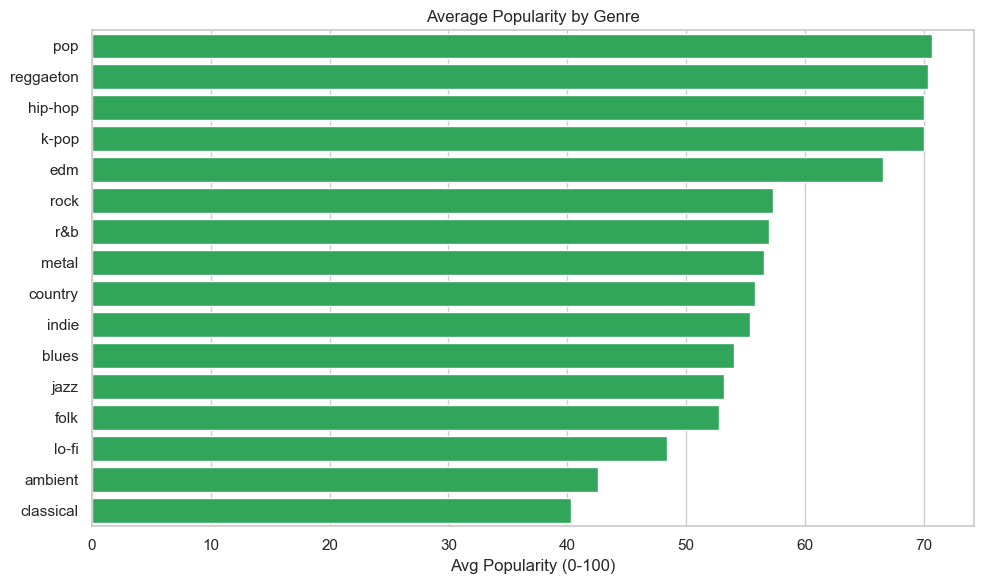

In [19]:
pop_by_genre = duckdb.sql("""
    SELECT genre, ROUND(AVG(popularity),1) AS avg_popularity
    FROM df GROUP BY genre ORDER BY avg_popularity DESC
""").df()

plt.figure(figsize=(10, 6))
sns.barplot(data=pop_by_genre, x="avg_popularity", y="genre", color="#1DB954")
plt.title("Average Popularity by Genre")
plt.xlabel("Avg Popularity (0-100)"); plt.ylabel("")
plt.tight_layout(); plt.savefig("../visuals/pop_by_genre.png", dpi=150); plt.show()

**V2 — Correlation heatmap ⭐**

The single most informative chart in this project. Reads at a glance: which audio
features move *with* popularity (warm) and which move *against* it (cool).

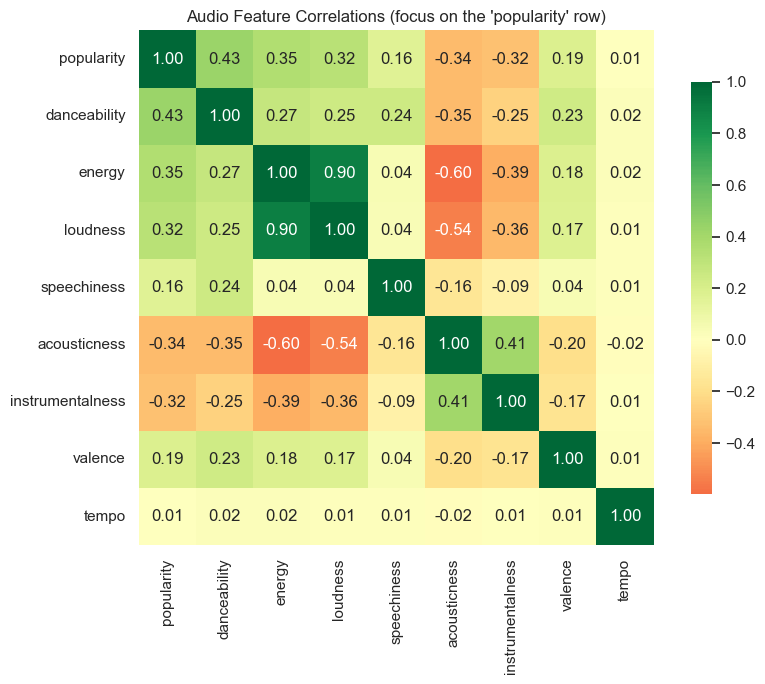

In [20]:
feature_cols = ["popularity","danceability","energy","loudness",
                "speechiness","acousticness","instrumentalness","valence","tempo"]
corr = df[feature_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Audio Feature Correlations (focus on the 'popularity' row)")
plt.tight_layout(); plt.savefig("../visuals/corr_heatmap.png", dpi=150); plt.show()

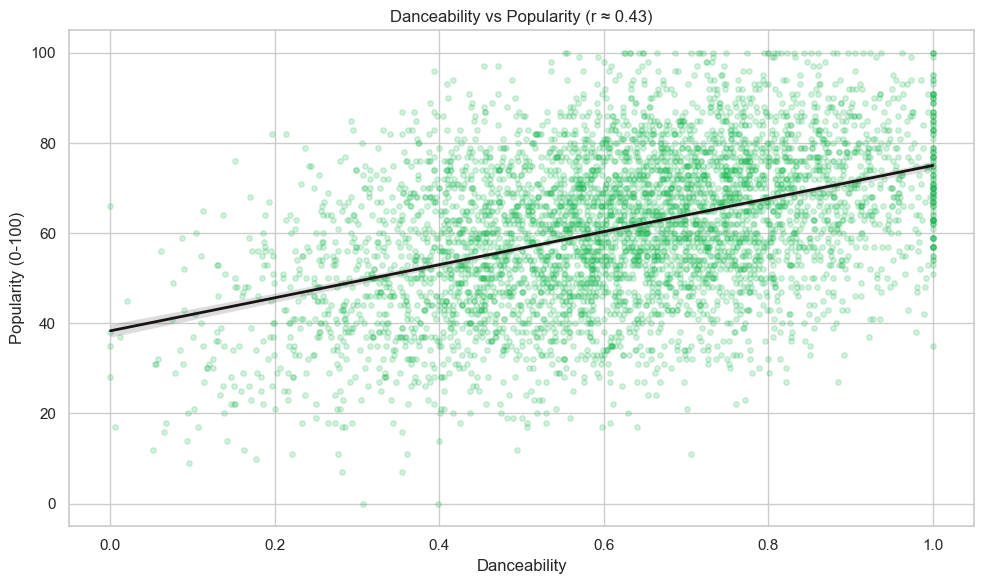

In [21]:
# V3 — Scatter: danceability vs popularity (visualizes the 0.43 correlation)
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df, x="danceability", y="popularity",
    scatter_kws={"alpha": 0.2, "s": 15, "color": "#1DB954"},
    line_kws={"color": "#191414", "linewidth": 2},
)
plt.title("Danceability vs Popularity (r ≈ 0.43)")
plt.xlabel("Danceability"); plt.ylabel("Popularity (0-100)")
plt.tight_layout()
plt.savefig("../visuals/danceability_vs_popularity.png", dpi=150)
plt.show()

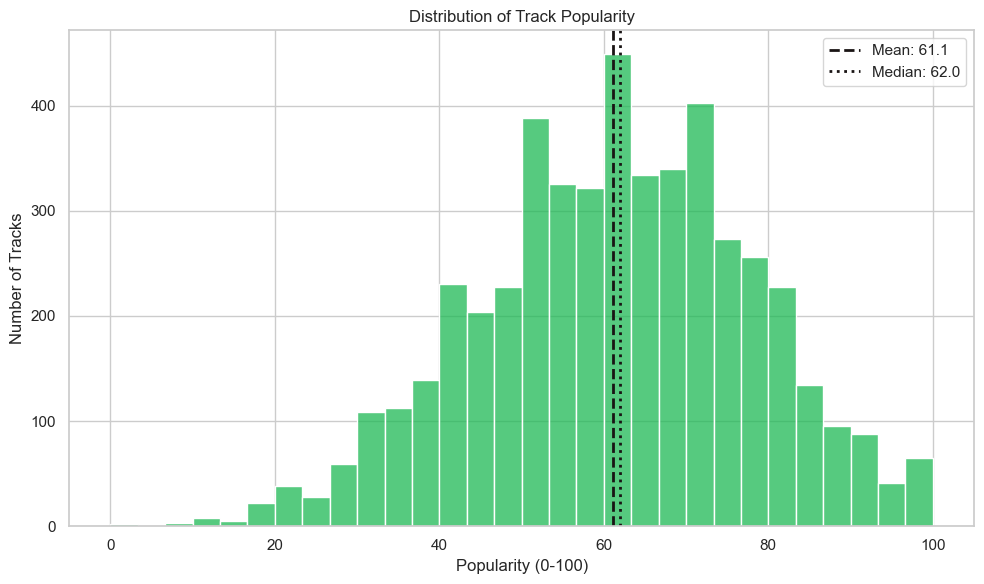

In [22]:
# V4 — Popularity distribution (THE Phase 7 hook)
plt.figure(figsize=(10, 6))
sns.histplot(df["popularity"], bins=30, color="#1DB954", edgecolor="white")
plt.axvline(df["popularity"].mean(), color="#191414", linestyle="--",
            linewidth=2, label=f"Mean: {df['popularity'].mean():.1f}")
plt.axvline(df["popularity"].median(), color="#191414", linestyle=":",
            linewidth=2, label=f"Median: {df['popularity'].median():.1f}")
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity (0-100)"); plt.ylabel("Number of Tracks")
plt.legend()
plt.tight_layout()
plt.savefig("../visuals/popularity_distribution.png", dpi=150)
plt.show()

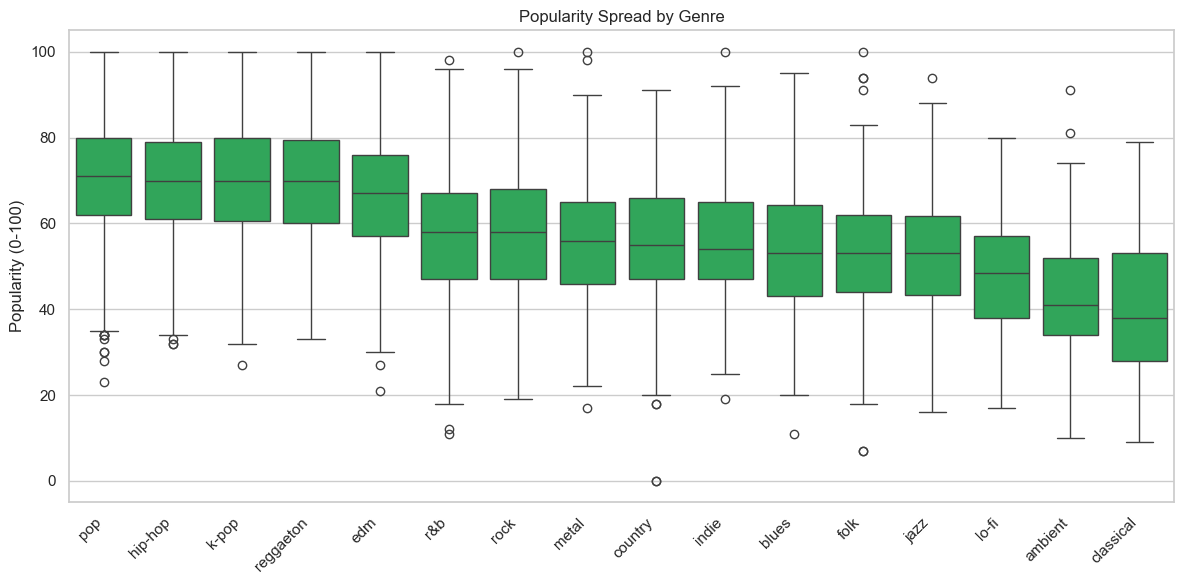

In [23]:
# V5 — Boxplot: popularity spread within each genre
genre_order = df.groupby("genre")["popularity"].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="genre", y="popularity", order=genre_order, color="#1DB954")
plt.title("Popularity Spread by Genre")
plt.xlabel(""); plt.ylabel("Popularity (0-100)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../visuals/popularity_by_genre_box.png", dpi=150)
plt.show()

## Phase 5 — Tell the story

**Finding 1 — Popular tracks are danceable, energetic, and vocal; tempo is irrelevant.**
Across nearly 5,000 tracks, popularity correlates positively with danceability (r = 0.43), energy (0.35), and loudness (0.33), and negatively with acousticness (−0.34) and instrumentalness (−0.33). Tempo shows essentially no relationship (r = 0.01). The platform's engagement rewards rhythm-forward, vocal-driven, high-energy music — and explicitly does *not* reward faster tempos, contrary to common assumptions about "catchy" music. *(Chart: V2 — correlation heatmap)*

**Finding 2 — Volume and popularity diverge: hip-hop punches far above its weight; rock punches below.**
The most numerous genres are pop (760 tracks), hip-hop (611), and rock (561). But ranked by *average* popularity (out of 100), the leaders are pop (70.7), reggaeton (70.4), hip-hop (70.0), and k-pop (70.0) — while rock (57.3) and country (55.8) sit ~15 points below despite their large catalogs. **Hip-hop has 9% fewer tracks than pop but matches its popularity exactly, while rock has 74% of pop's track count and trails it by 13 points in average popularity.** What gets *made* is not what gets *streamed*. *(Chart: V1 — popularity by genre)*

**Finding 3 — Popularity is bell-shaped around the mid-60s, not the long-tail skew typically associated with streaming.**
The distribution centers at mean 61.1 / median 62.0, with the mass between roughly 40 and 85 and no pronounced right tail of mega-hits. Mean ≈ median signals near-symmetry. This challenges the assumption that this dataset reflects Spotify's full long tail of obscure tracks — instead, it suggests a sample biased toward listed, already-known music, where most tracks have at least *some* audience traction. *(Chart: V4 — popularity histogram)*

**Finding 4 — Some genres are streaming roulette; others are reliably mid.**
Popularity *spread* (standard deviation) varies sharply by genre. The most volatile — biggest gap between hits and flops — are edm (σ = 13.9), k-pop (13.8), hip-hop (13.3), and reggaeton (13.3): these genres produce both big winners and forgettable misses. The most consistent genres cluster tightly around their averages with lower standard deviations. For a label or playlist curator, this distinction matters more than the average: a high-volatility genre needs more bets to land a hit, while a low-volatility genre offers steadier but capped returns. *(Chart: V5 — popularity boxplot by genre)*

**The "so what":** Engagement on this platform follows a clear formula — danceable, energetic, vocal — and that formula favors a handful of genres (pop, hip-hop, reggaeton, k-pop) that all share those traits. The gap between what's *catalogued* (rock and country at scale) and what's *streamed* (the rhythm-forward genres) suggests catalog volume is a lagging indicator of audience taste, not a leading one. The volatility data adds nuance: even within winning genres, hit-or-miss variance is high, so the bet structure of music investment matters more than picking the right genre alone.

**Limitations:** `popularity` is Spotify's recency-weighted composite score (0–100), not raw lifetime stream counts — it reflects *current* attention, not all-time plays. Observed correlations are modest (max r ≈ 0.43): real and consistent, but most variance in popularity is driven by factors *outside* the audio features (release timing, artist fame, playlist placement, marketing). Audio features predict the *shape* of popular music, not which specific tracks will hit.

In [24]:
# Phase 5 — pull exact numbers for the findings

print("=== F1: Correlations with popularity (signed, sorted) ===")
feature_cols = ["danceability","energy","loudness","speechiness",
                "acousticness","instrumentalness","valence","tempo"]
corrs = df[feature_cols + ["popularity"]].corr()["popularity"].drop("popularity")
print(corrs.sort_values(ascending=False).round(3))

print("\n=== F2: Genres by COUNT (Q1) vs by AVG POPULARITY (Q2) ===")
print(duckdb.sql("""
    SELECT genre,
           COUNT(*) AS tracks,
           ROUND(AVG(popularity), 1) AS avg_pop
    FROM df
    GROUP BY genre
    ORDER BY tracks DESC
""").df())

print("\n=== F3: Popularity distribution shape ===")
p = df["popularity"]
print(f"Mean:    {p.mean():.1f}")
print(f"Median:  {p.median():.1f}")
print(f"Std dev: {p.std():.1f}")
print(f"Skew:    {p.skew():.2f}  (>0 = right-skewed, <0 = left-skewed)")
print("Percentiles:")
for q in [0.10, 0.25, 0.50, 0.75, 0.90, 0.99]:
    print(f"  {int(q*100):>3}th: {p.quantile(q):.0f}")

print("\n=== F4: Most CONSISTENT vs most VOLATILE genres (popularity std dev) ===")
print(duckdb.sql("""
    SELECT genre,
           COUNT(*) AS tracks,
           ROUND(AVG(popularity), 1) AS avg_pop,
           ROUND(STDDEV(popularity), 1) AS std_pop
    FROM df
    GROUP BY genre
    HAVING COUNT(*) >= 50
    ORDER BY std_pop DESC
""").df())

=== F1: Correlations with popularity (signed, sorted) ===
danceability        0.429
energy              0.353
loudness            0.325
valence             0.189
speechiness         0.162
tempo               0.007
instrumentalness   -0.325
acousticness       -0.342
Name: popularity, dtype: float64

=== F2: Genres by COUNT (Q1) vs by AVG POPULARITY (Q2) ===
        genre  tracks  avg_pop
0         pop     760     70.7
1     hip-hop     611     70.0
2        rock     561     57.3
3         edm     466     66.6
4         r&b     301     57.0
5     country     282     55.8
6       indie     279     55.4
7   reggaeton     267     70.4
8       lo-fi     220     48.4
9       k-pop     215     70.0
10      metal     196     56.6
11       folk     181     52.8
12  classical     178     40.3
13       jazz     162     53.2
14      blues     124     54.0
15    ambient     122     42.6

=== F3: Popularity distribution shape ===
Mean:    61.1
Median:  62.0
Std dev: 16.7
Skew:    -0.18  (>0 = right-s

## Phase 7 — Comparative synthesis (after both projects) 🔭

This is where Netflix + Spotify become one portfolio-grade piece. You can't compare the
raw values (different units), but you CAN compare the **shapes and strategies**:

- **Concentration:** Is Spotify popularity a steep long-tail (few mega-hits) while
  Netflix's curated catalog spreads more evenly? Compare the *distribution shapes*
  (V4 here vs a Netflix equivalent), optionally with a Gini coefficient.
- **Curation vs scale:** Netflix ~8.8k deliberately chosen titles vs a vast, open
  music catalog — what does each strategy imply?
- **What "success" even means:** Netflix data reflects *acquisition* choices; Spotify
  `popularity` reflects *audience behavior*. Different signals entirely.

Save a normalized popularity-distribution figure here so Phase 7 has the data it needs.
